In [ ]:
%pylab inline
import pandas as pd
import numpy as np


Populating the interactive namespace from numpy and matplotlib


Скачаем подготовленные на семинаре данные:

In [ ]:
!wget  -O 'end_seminar.xlsx' -q 'https://www.dropbox.com/s/f4rm8sjc3v99p0m/_end_seminar.xlsx?dl=0'

Для пользователей Windows: скачайте файл самостоятельно и поместите его в папку с тетрадкой. Или попробуйте один из следующих вариантов:

In [ ]:
# !powershell iwr -outf somefile https://somesite/somefile

In [ ]:
# !pip install wget
# import wget
# wget.download('https://dropbox.com/s/f4rm8sjc3v99p0m/_end_seminar.xlsx?dl=1', 'end_seminar.xlsx')

##### В первой части задания (до раздела "Распределение студентов по курсам") использование циклов запрещается и повлечет за собой снижение оценки. Использование <code>vectorize</code> и  <code>apply</code>, <code>apply_along_axis</code> и всего, где можно применить лямбда-функции (`assign`, `map`, ...) крайне нежелательно

Для каждой задачи из этого раздела вы должны написать код для получения ответа, а также дать текстовый ответ, если он предполагается.

На некоторые вопросы вы можете получить путём пристального взгляда на таблицу, но это не будет засчитываться. Вы в любом случае должны получить ответ с помощью кода.

#### 1. [0.5 баллов] Откройте файл с таблицей (не забудьте про её формат). Выведите 3 последних строки.

Посмотрите на данные и скажите, что они из себя представляют, сколько в таблице строк, какие столбцы? (на это не надо отвечать, просто подумайте об этом)

In [ ]:
df = pd.read_excel('end_seminar.xlsx')
df.shape

(361, 16)

In [ ]:
df.tail(3)

,timestamp,id,rating,18_group,is_mi,fall_1,fall_2,fall_3,spring_1,spring_2,spring_3,is_first_time,percentile,17_group,blended,is_ml_student
358,2020-05-20 11:54:38.318,d7118b44c7e8fdbbaaca226d2da6fef1,1111,NaN,NaN,Сбор и обработка данных с помощью краудсорсинга,Statistical Learning Theory,Анализ неструктурированных данных,Проектирование и разработка высоконагруженных ...,Методы сжатия и передачи медиаданных,Численные методы,Да,0.652174,173.0,Соревновательный анализ данных,NaN
359,2020-05-23 21:16:40.916,79d14db48e4737af731960ae212d5134,966,NaN,NaN,Безопасность компьютерных систем,Принятие решений в условиях риска и неопределё...,Анализ неструктурированных данных,Проектирование и разработка высоконагруженных ...,Методы сжатия и передачи медиаданных,Компьютерное зрение,Да,0.985507,172.0,DevOps,NaN
360,2020-05-23 21:16:40.916,f2d210ace25a841e1e58036b257d5d47,1195,NaN,NaN,Анализ неструктурированных данных,Моделирование временных рядов,Высокопроизводительные вычисления,Обучение с подкреплением,Компьютерное зрение,Методы сжатия и передачи медиаданных,NaN,0.369565,176.0,Соревновательный анализ данных,NaN


### Ответьте на вопросы:
1. Сколько было уникальных пользователей из групп 18-го года набора, а сколько из групп 17-го года?

In [ ]:
df_18 = df[~df['18_group'].isna()]
df_17 = df[~df['17_group'].isna()]

print(f'Число уникальных пользователей из групп 18 года: {df_18["id"].nunique()}\nЧисло уникальных пользователей из групп 17 года: {df_17["id"].nunique()}')

Число уникальных пользователей из групп 18 года: 213
Число уникальных пользователей из групп 17 года: 134


2. Есть ли уникальные студенты с равными перцентилями?

In [ ]:
df_un = df[~df['id'].duplicated()]
df_un['percentile'].duplicated().sum() #есть пара дубликатов

1

In [ ]:
perc = df_un.loc[df_un['percentile'].duplicated(), 'percentile'].values[0]
print(f'Повторяющийся перцентиль равен {perc}')
df_un.loc[(df_un['percentile'] == perc), 'id'] #два студента с перцентилем 0

Повторяющийся перцентиль равен 0.0


,id
80,3e106aaef8b24dbb01319c73e14c2936
231,3a7326c9e355a67d3805824ca34c4bc5


#### 2. [0.5 балла] Есть ли в данных пропуски? В каких колонках? Сколько их в каждой из этих колонок?

Пропуски в колонках с номером группы: у студентов 17 года пропуски в столбце с номером группы 18, и наоборот; специализация МИ; первый ли раз заполняется форма; blended курсы (только у 17 года); является ли ствудентовм ML.

In [ ]:
print(df.isna().sum()) # кол-во пропущенных значений в каждом столбце

timestamp          0
id                 0
rating             0
18_group         138
is_mi            343
fall_1             0
fall_2             0
fall_3             0
spring_1           0
spring_2           0
spring_3           0
is_first_time      2
percentile         0
17_group         223
blended          223
is_ml_student    304
dtype: int64


In [ ]:
print(df_18.isna().sum()) # у студентов 18 года нет пропусков в 18_group

timestamp          0
id                 0
rating             0
18_group           0
is_mi            205
fall_1             0
fall_2             0
fall_3             0
spring_1           0
spring_2           0
spring_3           0
is_first_time      1
percentile         0
17_group         223
blended          223
is_ml_student    166
dtype: int64


In [ ]:
print(df_17.isna().sum()) # у студентов 17 года нет пропусков в 17_group и blended

timestamp          0
id                 0
rating             0
18_group         138
is_mi            138
fall_1             0
fall_2             0
fall_3             0
spring_1           0
spring_2           0
spring_3           0
is_first_time      1
percentile         0
17_group           0
blended            0
is_ml_student    138
dtype: int64


Заполните пропуски пустой строкой для строковых колонок, нулём для числовых и False для булевых (постарайтесь избежать перечисления названий всех столбцов).

In [ ]:
print(df.dtypes)

timestamp        datetime64[ns]
id                       object
rating                    int64
18_group                float64
is_mi                   float64
fall_1                   object
fall_2                   object
fall_3                   object
spring_1                 object
spring_2                 object
spring_3                 object
is_first_time            object
percentile              float64
17_group                float64
blended                  object
is_ml_student           float64
dtype: object


In [ ]:
df_num = df.select_dtypes(include='float').columns
df[df_num] = df[df_num].fillna(0)
df_obj = df.select_dtypes(include='object').columns
df[df_obj] = df[df_obj].fillna(value='')

In [ ]:
print(df.isna().sum())

timestamp        0
id               0
rating           0
18_group         0
is_mi            0
fall_1           0
fall_2           0
fall_3           0
spring_1         0
spring_2         0
spring_3         0
is_first_time    0
percentile       0
17_group         0
blended          0
is_ml_student    0
dtype: int64


#### 3. [0.5 балла] Посмотрите повнимательнее на колонку 'is_first_time'.

Каково процентное соотношение ответов? Сколько из них "Нет"?

In [ ]:
first_no = round((df['is_first_time'] == 'Нет').sum() / (df['is_first_time'] != '').sum() * 100, 2)
first_yes = round((df['is_first_time'] == 'Да').sum() / (df['is_first_time'] != '').sum() * 100, 2)
print(f'{first_no}% не впервые заполняли форму, {first_yes}% - впервые \nКоличество "Нет" - {(df["is_first_time"] == "Нет").sum()}')

14.21% не впервые заполняли форму, 85.79% - впервые 
Количество "Нет" - 51


Если вы найдете повторные обращения студентов, оставьте только самую позднюю версию. В дальнейших заданиях используйте версию данных без повторов.

<i>Обращения со значением "Нет" в 'is_first_time' могут быть как повторными, так и первичными, поскольку поле заполняли сами студенты.</i>

In [ ]:
df = df.sort_values(by='timestamp', ascending=False).drop_duplicates(subset='id')

#### 4. [0.5 балла] Какие  blended-курсы для четверокурсников существуют? На какой blended-курс записалось наибольшее количество студентов? На каком из blended-курсов собрались студенты с самым высоким средним рейтингом (выведите этот курс и количество студентов на нем)?

In [ ]:
print('3 blended-курса (в таблице). На курс DevOps записалось больше всего человек. \nНа курсе Введение в дифференциальную геометрию самый высокий средний рейтинг, на нем 15 студентов')
df.groupby('blended').agg({'id':'count', 'rating':'mean'})[1:]

3 blended-курса (в таблице). На курс DevOps записалось больше всего человек. 
На курсе Введение в дифференциальную геометрию самый высокий средний рейтинг, на нем 15 студентов


,id,rating
blended,,
DevOps,87,1154.172414
Введение в дифференциальную геометрию,15,1210.733333
Соревновательный анализ данных,32,1144.218750


#### 5. [1 балл] Выясните, есть ли студенты с абсолютно одинаковыми предпочтениями по всем курсам.

Для этого сформируйте таблицу, где для каждого возможного набора курсов посчитано количество студентов, выбравших такой набор, и оставьте только строки где это количество больше 1.

В данном случае набор курсов задается упорядоченным множеством ('fall_1', 'fall_2', 'fall_3', 'spring_1', 'spring_2', 'spring_3', 'blended'). Элемент blended будет нулевым для 3-го курса.

In [ ]:
col = ['fall_1', 'fall_2', 'fall_3', 'spring_1', 'spring_2', 'spring_3', 'blended']

In [ ]:
df_set = df.groupby(col)['id'].count()
df_courses = pd.DataFrame({'Наборы_курсов': np.array(df_set.index), 'Количество_студентов': df_set.values})
df_courses.head(5)

,Наборы_курсов,Количество_студентов
0,"(Statistical Learning Theory, Анализ неструкту...",2
1,"(Statistical Learning Theory, Анализ неструкту...",1
2,"(Statistical Learning Theory, Байесовские мето...",1
3,"(Statistical Learning Theory, Байесовские мето...",1
4,"(Statistical Learning Theory, Байесовские мето...",1


In [ ]:
df_courses[df_courses['Количество_студентов'] > 1]

,Наборы_курсов,Количество_студентов
0,"(Statistical Learning Theory, Анализ неструкту...",2
60,"(Байесовские методы машинного обучения, Анализ...",2
62,"(Байесовские методы машинного обучения, Анализ...",2
72,"(Безопасность компьютерных систем, Statistical...",3
84,"(Безопасность компьютерных систем, Высокопроиз...",2
102,"(Безопасность компьютерных систем, Высокопроиз...",3
105,"(Безопасность компьютерных систем, Высокопроиз...",2
113,"(Безопасность компьютерных систем, Матричные в...",2
137,"(Безопасность компьютерных систем, Сбор и обра...",2
155,"(Безопасность компьютерных систем, Теория баз ...",2


#### 6. [0.5 балла] Найдите курсы по выбору, на которые записывались как студенты 18-го года набора, так и студенты 17-го года.

In [ ]:
courses_18 = np.unique(df.loc[df['18_group'] != 0, col])
courses_17 = np.unique(df.loc[df['17_group'] != 0, col])
set(courses_18) & set(courses_17)

{'Statistical Learning Theory',
 'Безопасность компьютерных систем',
 'Высокопроизводительные вычисления',
 'Моделирование временных рядов',
 'Принятие решений в условиях риска и неопределённости',
 'Сбор и обработка данных с помощью краудсорсинга',
 'Численные методы'}

Методом исключения найдите курсы, которые предлагались только студентам 18-го года и только студентам 17-го года.

In [ ]:
print(f'Только студентам 18 года: \n{set(courses_18[1:]) - set(courses_17)} \n')
print(f'Только студентам 17 года: \n{set(courses_17) - set(courses_18)}')

Только студентам 18 года: 
{'Анализ данных в бизнесе', 'Промышленное программирование на языке Java', 'Теория баз данных', 'Компьютерные сети', 'Матричные вычисления', 'Машинное обучение 2', 'Язык SQL', 'Дополнительные главы прикладной статистики', 'Дискретная оптимизация', 'Системы баз данных'} 

Только студентам 17 года: 
{'Генеративные модели в машинном обучении', 'Обучение с подкреплением', 'Глубинное обучение в обработке звука', 'Соревновательный анализ данных', 'Конфликты и кооперация', 'Введение в дифференциальную геометрию', 'Методы сжатия и передачи медиаданных', 'DevOps', 'Компьютерное зрение', 'Байесовские методы машинного обучения', 'Символьные вычисления', 'Проектирование и разработка высоконагруженных сервисов', 'Анализ неструктурированных данных'}


### Визуализации и matplotlib

При работе с данными часто неудобно делать какие-то выводы, если смотреть на таблицу и числа в частности, поэтому важно уметь визуализировать данные. Здесь будут описаны ключевые правила оформления графиков для **всех** домашних заданий.

У matplotlib, конечно же, есть [документация](https://matplotlib.org/users/index.html) с большим количеством [примеров](https://matplotlib.org/examples/), но для начала достаточно знать про несколько основных типов графиков:
- plot — обычный поточечный график, которым можно изображать кривые или отдельные точки;
- hist — гистограмма, показывающая распределение некоторой величины;
- scatter — график, показывающий взаимосвязь двух величин;
- bar — столбцовый график, показывающий взаимосвязь количественной величины от категориальной.

В этом задании вы попробуете построить один из них. Не забывайте про базовые принципы построения приличных графиков:
- оси должны быть подписаны, причём не слишком мелко;
- у графика должно быть название;
- если изображено несколько графиков, то необходима поясняющая легенда;
- все линии на графиках должны быть чётко видны (нет похожих цветов или цветов, сливающихся с фоном);
- если отображена величина, имеющая очевидный диапазон значений (например, проценты могут быть от 0 до 100), то желательно масштабировать ось на весь диапазон значений (исключением является случай, когда вам необходимо показать малое отличие, которое незаметно в таких масштабах);
- сетка на графике помогает оценить значения в точках на глаз, это обычно полезно, поэтому лучше ее отрисовывать;
- если распределение на гистограмме имеет тяжёлые хвосты, лучше использовать логарифмическую шкалу.

Еще одна билиотека для визуализации: [seaborn](https://jakevdp.github.io/PythonDataScienceHandbook/04.14-visualization-with-seaborn.html) (обычно сокращается до sns). Это настройка над matplotlib, иногда удобнее и красивее делать визуализации через неё.

**5 пунктов после которых ваши графики не будут прежними:**
- для красивой картинки <code>%config InlineBackend.figure_format = 'retina'</code>
- задаем размер (почти) всех графиков (можно выбрать другие значения) <code>plt.rcParams['figure.figsize'] = 8, 5</code>
- размер шрифта подписей графиков <code>plt.rcParams['font.size'] = 12</code>
- формат в котором сохраняется изображение <code>mpl.rcParams['savefig.format'] = 'pdf'</code>
- sns – seaborn, добавляет решетку <code>sns.set_style('darkgrid')</code>

Добавьте эти функции в ячейку ниже. Каждый график все равно придется настраивать отдельно, но указанные строчки позволят значительно упростить процесс.  

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

%config InlineBackend.figure_format = 'retina'
plt.rcParams['figure.figsize'] = 8, 5
plt.rcParams['font.size'] = 10
mpl.rcParams['savefig.format'] = 'pdf'
sns.set_style('darkgrid')

#### 7. [0.5 балла] Постройте график средних рейтингов по дням получения ответов (bar plot).

In [ ]:
df_rating = df.groupby(df['timestamp'].dt.date)['rating'].mean()

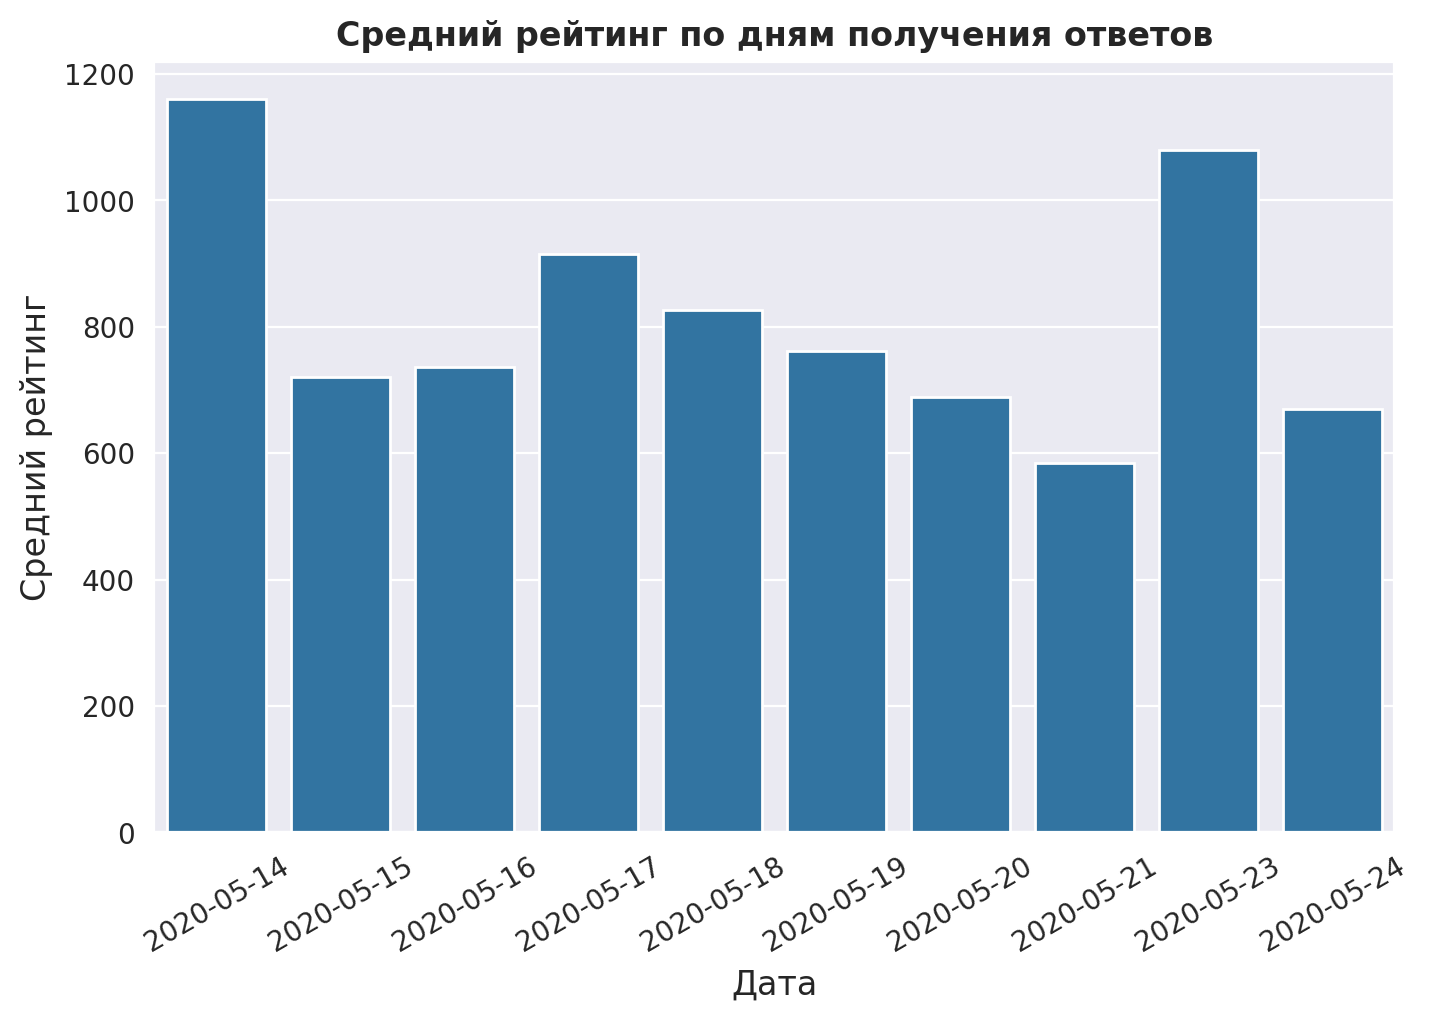

In [ ]:
fig, ax = plt.subplots()
ax = sns.barplot(data=df_rating)
ax.set_xlabel('Дата', fontsize=12)
ax.set_ylabel('Средний рейтинг', fontsize=12)
ax.set_title('Средний рейтинг по дням получения ответов', fontsize=12, fontweight='heavy')
ax.tick_params(axis='x', labelrotation=30);

Сохраните график в формате pdf (так он останется векторизованным).

In [ ]:
fig.savefig(fname='mean_rating.pdf', bbox_inches = "tight")

### 2. Распределение студентов по курсам.

<span style="color:red">!!!ВНИМАТЕЛЬНО ИЗУЧИТЕ ТЕКСТ НИЖЕ!!!</span>.

<span style="color:orange">Если во время выполнения заданий у вас вознинут вопросы -- еще раз перечитайте текст целиком, скорее всего ответы уже содержатся в нем.</span>

Теперь вам нужно распределить студентов по осенним курсам по выбору, учитывая их предпочтения.

## 📌 **Алгоритм распределения студентов по курсам**:
1. По умолчанию на каждой дисциплине по выбору у 3 и 4 курсов может учиться 1 группа (до 30 студентов). Исключения описаны ниже. На blended-дисциплинах для четверокурсников количество мест не ограничено.
2. Проводится первая волна отбора. Для каждой дисциплины формируется список тех, кто указал её первым приоритетом (если студент должен выбрать два курса по выбору, то для него дисциплины, которые он указал первым и вторым приоритетом, рассматриваются как дисциплины первого приоритета). Если желающих больше, чем мест, то выбирается топ по перцентилю рейтинга.
3. На дисциплинах, где остались места после первой волны, формируются списки тех, кто выбрал их вторым приоритетом, и места заполняются лучшими по перцентили рейтинга студентами. После этого проводится такая же процедура для дисциплин третьего приоритета.
4. Если студент не попал на необходимое количество курсов по итогам трёх волн, с ним связывается учебный офис и решает вопрос в индивидуальном порядке.

## ☝️ **Обращаем ваше внимание на следующие детали:**
- Конкурс на каждый курс общий для 3-го и 4-го курса

- По умолчанию студент выбирает один осенний и один весенний курс по выбору, а также четверокурсники выбирают один blended-курс. Студенты групп 17-го года специализаций МОП и ТИ выбирают по 2 осенних и 2 весенних курса по выбору, также студенты групп 18' специализации МИ выбирают 2 осенних курса. <i>Для студентов, которые выбирают 2 курса (например, осенних) первый приоритет — <code>fall_1</code> и <code>fall_2</code>, второй приоритет — <code>fall_3</code>. Такие студенты участвуют только в двух волнах отбора</i>.

- Студенты специализации МОП не могут выбрать весенним курсом по выбору Машинное обучение 2. **Если студент специализации МОП выбрал Машинное обучение 2, то его приоритеты сдвигаются.** Из-за совпадений первого и второго курса по выбору двигать приоритеты не надо.

- Blended-курсы не трогайте, по ним не надо распределять, на другие курсы они никак не влияют.

- Заведомо известно, что в процессе распределения не возникнет ситуации, когда на одно место претендуют студенты с одинаковым перцентилем.

- Постарайтесь воздержаться от использования циклов там, где это возможно. <i>Допустимо итерироваться по <b>курсам</b>, на которые проводится отбор, и по <b>волнам</b> отбора. Если вы придумаете, как обойтись и без этих циклов, то на усмотрение проверяющего могут быть добавлены бонусные баллы. <b>Дублирование кода не признается успешным избавлением от циклов</b></i>

- На выходе ожидается файл res_fall.csv с результатами распределения на осенние курсы по выбору. Файл должен быть следующего формата:

    * Три колонки: ID, course1, course2
    
    * Если студент не попал на курс, но должен был, то вместо названия курса в ячейке должна быть строка "???"
    
    * Если студент должен выбрать только один курс, то в колонке course2 для него должна стоять строка "-"
    
    * Если студент должен выбрать два курса по выбору, то порядок в колонках course1 и course2 не важен.
    
    * hint: для сохранения воспользуйтесь `df.to_csv('solution.csv', index=None)`
    

Для работы вам могут понадобиться следующие данные:

- Результаты опроса (вы уже использовали этот файл в первой части задания, но на всякий случай ссылка: https://www.dropbox.com/s/f4rm8sjc3v99p0m/_end_seminar.xlsx?dl=0)

- Соответствие номеров групп специализациям:

    * 171, 172 - МОП; 173 - ТИ; 174 — АДИС; 175, 176 — РС; 177 — АПР
    
    * У студентов 18-го года номера групп соответствуют номерам до распределения по специализациям. Это означает, что по номеру группы 18* нельзя однозначно определить специализацию студента. При этом в рамках распределения важно знать информацию только о двух из них: МОП и МИ. Эти знание можно получить из колонок 'is_ml_student
' и 'is_mi' соответственно.

- Ограничения по количеству мест на курсах по выбору:

    * Осенние: везде 30 мест, кроме Statistical Learning Theory (60 мест), Высокопроизводительных вычислений (60 мест), Анализа неструктурированных данных ($\infty$ мест)

    * Весенние: везде 30 мест, кроме Обучения с подкреплением (60 мест), Анализа данных в бизнесе (60 мест).


Кстати, убедитесь, что в данных больше нет пропусков и повторных записей.

#### 0. Проверка

Для начала давайте убедимся, что вы успешно выполнили задания первой части и проверим ваши данные на наличие пропусков и повторов:

In [ ]:
assert df.shape[0] == 347, 'В таблице остались повторы или потеряны данные'

assert df.isna().sum().sum() == 0, 'В таблице остались пропуски'

Если вы не получили AssertionError, то можете продолжать.

#### 1. [1 балл] Создайте новый признак, обозначающий, сколько осенних курсов должен выбрать студент

В этом вам может помочь информация о специализации и группе стундента.

In [ ]:
num_fall = ((df['is_mi'] == 1) |
           (df['17_group'] % 10 == 1) |
           (df['17_group'] % 10 == 2) |
           (df['17_group'] % 10 == 3)) + 1
df['num_fall'] = num_fall

Проверка:

In [ ]:
col_name = 'num_fall'   # insert your new column name as str

assert(df[df['id'] == '2662600c2c37e11e62f6ee0b88452f22'][col_name] == 2).all()
assert(df[df['id'] == 'd555d2805e1d93d4f023e57dc4c8f403'][col_name] == 2).all()
assert(df[df['id'] == '8fe79f84f36e3a5d2d6745621321302c'][col_name] == 1).all()
assert(df[df['id'] == 'e4caca755ee0bdd711e18fb8084958b5'][col_name] == 1).all()

#### 2. [2 балла] Распределите студентов в соответствии с первым приоритетом

In [ ]:
res_fall = pd.DataFrame({'id': df['id'], 'course1': '???', 'course2': np.where(df['num_fall'] == 1, '-', '???'), 'percentile': df['percentile']})

In [ ]:
courses_fall = np.unique(df[['fall_1', 'fall_2']])
special = np.array(['Statistical Learning Theory', 'Высокопроизводительные вычисления', 'Анализ неструктурированных данных'])
df_sorted = df.sort_values(by='percentile')

for course in courses_fall:
    if course not in special:
        ids = df_sorted[(df_sorted['fall_1'] == course) |
                        ((df_sorted['num_fall'] == 2) &
                         (df_sorted['fall_2'] == course))][:30]['id'].values
        res_fall.loc[(res_fall['id'].isin(ids)) &
                     (res_fall['course1'] == '???'), 'course1'] = course
        res_fall.loc[(res_fall['id'].isin(ids)) &
                     (res_fall['course1'] != course) &
                     (res_fall['course2'] == '???'), 'course2'] = course

    elif course in np.array(['Statistical Learning Theory', 'Высокопроизводительные вычисления']):
        ids = df_sorted[(df_sorted['fall_1'] == course) |
                        ((df_sorted['num_fall'] == 2) &
                         (df_sorted['fall_2'] == course))][:60]['id'].values
        res_fall.loc[(res_fall['id'].isin(ids)) &
                     (res_fall['course1'] == '???'), 'course1'] = course
        res_fall.loc[(res_fall['id'].isin(ids)) &
                     (res_fall['course1'] != course) &
                     (res_fall['course2'] == '???'), 'course2'] = course

    elif course == 'Анализ неструктурированных данных':
        ids = df_sorted[(df_sorted['fall_1'] == course) |
                        ((df_sorted['num_fall'] == 2) &
                         (df_sorted['fall_2'] == course))]['id'].values
        res_fall.loc[(res_fall['id'].isin(ids)) &
                     (res_fall['course1'] == '???'), 'course1'] = course
        res_fall.loc[(res_fall['id'].isin(ids)) &
                     (res_fall['course1'] != course) &
                     (res_fall['course2'] == '???'), 'course2'] = course

In [ ]:
is_first_place = np.zeros((df['id'].shape))
is_last_place = np.zeros((df['id'].shape))

for course in courses_fall:
   min_per = res_fall.loc[(res_fall['course1'] == course) | (res_fall['course2'] == course), 'percentile'].min()
   max_per = res_fall.loc[(res_fall['course1'] == course) | (res_fall['course2'] == course), 'percentile'].max()
   is_first_place += ((res_fall['percentile'] == min_per) & ((res_fall['course1'] == course) | (res_fall['course2'] == course)))
   is_last_place += ((res_fall['percentile'] == max_per) & ((res_fall['course1'] == course) | (res_fall['course2'] == course)))

is_first_place = is_first_place != 0
is_first_place = np.where(is_first_place == False, np.nan, is_first_place)
is_last_place = is_last_place != 0
is_last_place = np.where(is_last_place == False, np.nan, is_last_place)

df['is_first_place'] = is_first_place
df['is_last_place'] = is_last_place

Здесь для проверки приведена таблица, в которой есть 2 дополнительные колонки:
    
    1) is_first_place - является ли студент лучшим по перцентили хотя бы на одном из курсов, куда он был зачислен
    (True / NaN)
    
    2) is_last_place  - является ли студент худшим по перцентили хотя бы на одном из курсов, куда он был зачислен (True / NaN)

In [ ]:
!wget  -O '2_task_check.csv' -q 'https://www.dropbox.com/s/v8o2zzq3iz5gc9w/_2_task_check.csv?dl=0'
check_df = pd.read_csv('2_task_check.csv')

После распределения студентов в соответствии с первым приоритетом добавьте в свой датафрейм аналогичные признаки и запустите проверку:

In [ ]:
fir_col_name = 'is_first_place'   # insert name of your new column with is_first_place as str
last_col_name = 'is_last_place'    # insert name of your new column with is_last_place as str


assert((df[df[fir_col_name].isna() == False][['id']].sort_values('id').reset_index(drop=True)
        ==
        check_df[check_df['is_first_place'].isna() == False][['id']].sort_values('id').reset_index(drop=True)
       ).id.values).all()


assert((df[df[last_col_name].isna() == False][['id']].sort_values('id').reset_index(drop=True)
       ==
       check_df[check_df['is_last_place'].isna() == False][['id']].sort_values('id').reset_index(drop=True)
      ).id.values).all()

#### 3. [2 балла] Проведите все три волны отбора студентов на курсы по выбору

In [ ]:
courses_fall_2 = np.unique(df[['fall_2', 'fall_3']])
special = np.array(['Statistical Learning Theory', 'Высокопроизводительные вычисления', 'Анализ неструктурированных данных'])
not_accept = res_fall.loc[(res_fall['course1'] == '???') | (res_fall['course2'] == '???'), 'id']
df2_sorted = df[df['id'].isin(not_accept)].sort_values(by='percentile')

for course in courses_fall_2:
    if course not in special:
        places = ((res_fall['course1'] == course) | (res_fall['course2'] == course)).sum()
        if places < 30:
            accept = res_fall.loc[(res_fall['course1'] == course) | (res_fall['course2'] == course), 'id'].values
            ids = df2_sorted[((df2_sorted['fall_2'] == course) &
                              (df2_sorted['num_fall'] == 1)) |
                             ((df2_sorted['num_fall'] == 2) &
                              (df2_sorted['fall_3'] == course)) &
                             (~df2_sorted['id'].isin(accept))][:(30 - places)]['id'].values

            res_fall.loc[(res_fall['id'].isin(ids)) &
                         (res_fall['course1'] == '???'), 'course1'] = course
            res_fall.loc[(res_fall['id'].isin(ids)) &
                         (res_fall['course2'] == '???'), 'course2'] = course

    elif course in np.array(['Statistical Learning Theory', 'Высокопроизводительные вычисления']):
        places = ((res_fall['course1'] == course) | (res_fall['course2'] == course)).sum()
        if places < 60:
            accept = res_fall.loc[(res_fall['course1'] == course) | (res_fall['course2'] == course), 'id'].values
            ids = df2_sorted[((df2_sorted['fall_2'] == course) &
                              (df2_sorted['num_fall'] == 1)) |
                             ((df2_sorted['num_fall'] == 2) &
                              (df2_sorted['fall_3'] == course)) &
                             (~df2_sorted['id'].isin(accept))][:(60 - places)]['id'].values

            res_fall.loc[(res_fall['id'].isin(ids)) &
                         (res_fall['course1'] == '???'), 'course1'] = course
            res_fall.loc[(res_fall['id'].isin(ids)) &
                         (res_fall['course1'] != course) &
                         (res_fall['course2'] == '???'), 'course2'] = course

    elif course == 'Анализ неструктурированных данных':
        accept = res_fall.loc[(res_fall['course1'] == course) | (res_fall['course2'] == course), 'id'].values
        ids = df2_sorted[((df2_sorted['fall_2'] == course) &
                          (df2_sorted['num_fall'] == 1)) |
                         ((df2_sorted['num_fall'] == 2) &
                          (df2_sorted['fall_3'] == course)) &
                         (~df2_sorted['id'].isin(accept))]['id'].values

        res_fall.loc[(res_fall['id'].isin(ids)) &
                     (res_fall['course1'] == '???'), 'course1'] = course
        res_fall.loc[(res_fall['id'].isin(ids)) &
                     (res_fall['course1'] != course) &
                     (res_fall['course2'] == '???'), 'course2'] = course

In [ ]:
courses_fall_3 = np.unique(df['fall_3'])
special = np.array(['Statistical Learning Theory', 'Высокопроизводительные вычисления', 'Анализ неструктурированных данных'])
not_accept2 = res_fall.loc[(res_fall['course1'] == '???') & (res_fall['course2'] == '-'), 'id']
df3_sorted = df[df['id'].isin(not_accept2)].sort_values(by='percentile')

for course in courses_fall_3:
    if course not in special:
        places = ((res_fall['course1'] == course) | (res_fall['course2'] == course)).sum()
        if places < 30:
            accept = res_fall.loc[(res_fall['course1'] == course) | (res_fall['course2'] == course), 'id'].values
            ids = df3_sorted[((df3_sorted['fall_3'] == course) &
                              (df3_sorted['num_fall'] == 1)) &
                             (~df3_sorted['id'].isin(accept))][:(30 - places)]['id'].values

            res_fall.loc[(res_fall['id'].isin(ids)) &
                         (res_fall['course1'] == '???'), 'course1'] = course

    elif course in np.array(['Statistical Learning Theory', 'Высокопроизводительные вычисления']):
        places = ((res_fall['course1'] == course) | (res_fall['course2'] == course)).sum()
        if places < 60:
            accept = res_fall.loc[(res_fall['course1'] == course) | (res_fall['course2'] == course), 'id'].values
            ids = df3_sorted[((df3_sorted['fall_3'] == course) &
                              (df3_sorted['num_fall'] == 1)) &
                             (~df3_sorted['id'].isin(accept))][:(60 - places)]['id'].values

            res_fall.loc[(res_fall['id'].isin(ids)) &
                         (res_fall['course1'] == '???'), 'course1'] = course

    elif course == 'Анализ неструктурированных данных':
        accept = res_fall.loc[(res_fall['course1'] == course) | (res_fall['course2'] == course), 'id'].values
        ids = df3_sorted[((df3_sorted['fall_3'] == course) &
                          (df3_sorted['num_fall'] == 1)) &
                         (~df3_sorted['id'].isin(accept))]['id'].values

        res_fall.loc[(res_fall['id'].isin(ids)) &
                     (res_fall['course1'] == '???'), 'course1'] = course

In [ ]:
res_fall.drop('percentile', axis=1, inplace=True)
res_fall.rename(columns={'id':'ID'}, inplace=True)

In [ ]:
res_fall.to_csv('res_fall.csv', index=None)

**Отправьте свой файл res_fall.csv в контест (будет в ближайшее время, следите за новостями) и прикрепите/укажите ниже ваш никнейм и ссылку на успешную посылку.**

Никнейм: l1monnovva

Посылка: https://contest.yandex.ru/contest/68637/run-report/120292884/

ID посылки 120292884

*Дисклеймер:*

Успешная посылка в контесте является **обязательным** условием получения полного балла за этот (и следующий) пункт. Если добиться успешной посылки не удастся, баллы будут выставляться на усмотрение проверяюшего.

При этом ОК в контесте не гарантирует полный балл. Оценка всё равно может быть снижена в случае обнаружения неэффективностей или ошибок в коде. Если вы сдадите в AnyTask очевидно неработающий код или ноутбук без кода, но при этом в контест будет сдан корректный файл, то это будет расцениваться как плагиат.

На всякий случай просим вас сдать вместе с ноутбуком файл res_fall.csv в anytask

### 4. [1 балла] Распределите таким же образом студентов еще и на весенние курсы по выбору.

Если ваш код был хорошо структурирован, то это не составит проблем.

Если вы выполнили это задание, сдайте среди прочего файл res_spring.csv в таком же формате, как и res_fall.csv.

In [ ]:
num_spring = ((df['17_group'] % 10 == 1) |
              (df['17_group'] % 10 == 2) |
              (df['17_group'] % 10 == 3)) + 1
df['num_spring'] = num_spring

In [ ]:
res_spring = pd.DataFrame({'id': df['id'], 'course1': '???', 'course2': np.where(df['num_spring'] == 1, '-', '???'), 'percentile': df['percentile']})

In [ ]:
# нет студентов
df[(df['num_spring'] == 2) & ((df['spring_1'] == 'Машинное обучение 2') | (df['spring_2'] == 'Машинное обучение 2') | (df['spring_3'] == 'Машинное обучение 2'))]

,timestamp,id,rating,18_group,is_mi,fall_1,fall_2,fall_3,spring_1,spring_2,spring_3,is_first_time,percentile,17_group,blended,is_ml_student,num_fall,is_first_place,is_last_place,num_spring


In [ ]:
courses_spring = np.unique(df[['spring_1', 'spring_2']])
special_spring = np.array(['Обучение с подкреплением', 'Анализ данных в бизнесе'])
df_sorted = df.sort_values(by='percentile')

for course in courses_spring:
    if course not in special_spring:
        if course != 'Машинное обучение 2':
            ids = df_sorted[((df_sorted['is_ml_student'] == 0) &
                             ((df_sorted['spring_1'] == course) |              # здесь я не проверяю, есть ли студенты, которые должны выбрать 2 курса, выбравшие МО 2
                              ((df_sorted['num_spring'] == 2) &                  # так как ранее я проверила, что таких студентов нет
                               (df_sorted['spring_2'] == course)))) |
                               ((df_sorted['is_ml_student'] == 1) &
                             ((df_sorted['num_spring'] == 1) &
                              (df_sorted['spring_1'] == 'Машинное обучение 2') &
                              (df_sorted['spring_2'] == course)) |
                             ((df_sorted['num_spring'] == 1) &
                              (df_sorted['spring_1'] == 'Машинное обучение 2') &
                              (df_sorted['spring_2'] == 'Машинное обучение 2') &
                              (df_sorted['spring_3'] == course)))][:30]['id'].values
        else:
            ids = df_sorted[(df_sorted['is_ml_student'] == 0) &
                            ((df_sorted['spring_1'] == course) |
                             ((df_sorted['num_spring'] == 2) &
                             (df_sorted['spring_2'] == course)))][:30]['id'].values

        res_spring.loc[(res_spring['id'].isin(ids)) &
                    (res_spring['course1'] == '???'), 'course1'] = course
        res_spring.loc[(res_spring['id'].isin(ids)) &
                    (res_spring['course1'] != course) &
                    (res_spring['course2'] == '???'), 'course2'] = course

    elif course in special_spring:
        ids = df_sorted[(df_sorted['spring_1'] == course) |
                        ((df_sorted['num_spring'] == 2) &
                         (df_sorted['spring_2'] == course))][:60]['id'].values
        res_spring.loc[(res_spring['id'].isin(ids)) &
                     (res_spring['course1'] == '???'), 'course1'] = course
        res_spring.loc[(res_spring['id'].isin(ids)) &
                     (res_spring['course1'] != course) &
                     (res_spring['course2'] == '???'), 'course2'] = course

In [ ]:
courses_spring_2 = np.unique(df[['spring_2', 'spring_3']])
special_spring = np.array(['Обучение с подкреплением', 'Анализ данных в бизнесе'])
not_accept = res_spring.loc[(res_spring['course1'] == '???') | (res_spring['course2'] == '???'), 'id']
df2_sorted = df[df['id'].isin(not_accept)].sort_values(by='percentile')

for course in courses_spring_2:
    if course not in special_spring:
        places = ((res_spring['course1'] == course) | (res_spring['course2'] == course)).sum()
        if places < 30:
            if course != 'Машинное обучение 2':
                accept = res_spring.loc[(res_spring['course1'] == course) | (res_spring['course2'] == course), 'id'].values
                ids = df2_sorted[(~df2_sorted['id'].isin(accept)) &
                                ((df2_sorted['is_ml_student'] == 0) &
                                 (((df2_sorted['spring_2'] == course) &
                                   (df2_sorted['num_spring'] == 1)) |              # здесь я не проверяю, есть ли студенты, которые должны выбрать 2 курса, выбравшие МО 2
                                  ((df2_sorted['num_spring'] == 2) &                  # так как ранее я проверила, что таких студентов нет
                                   (df2_sorted['spring_3'] == course)))) |
                                   ((df2_sorted['is_ml_student'] == 1) &
                                    ((df2_sorted['num_spring'] == 1) &
                                     (df2_sorted['spring_1'] == 'Машинное обучение 2') &
                                     (df2_sorted['spring_3'] == course) &
                                     (df2_sorted['spring_2'] != 'Машинное обучение 2')))][:(30 - places)]['id'].values
            else:
                ids = df2_sorted[(df2_sorted['is_ml_student'] == 0) &
                                (((df2_sorted['spring_2'] == course) &
                                (df2_sorted['num_spring'] == 1)) |
                                ((df2_sorted['num_spring'] == 2) &
                                (df2_sorted['spring_3'] == course)))][:(30 - places)]['id'].values
            res_spring.loc[(res_spring['id'].isin(ids)) &
                        (res_spring['course1'] == '???'), 'course1'] = course
            res_spring.loc[(res_spring['id'].isin(ids)) &
                        (res_spring['course2'] == '???'), 'course2'] = course

    elif course in special_spring:
        places = ((res_spring['course1'] == course) | (res_spring['course2'] == course)).sum()
        if places < 60:
            accept = res_spring.loc[(res_spring['course1'] == course) | (res_spring['course2'] == course), 'id'].values
            ids = df2_sorted[((df2_sorted['spring_2'] == course) &
                              (df2_sorted['num_spring'] == 1)) |
                             ((df2_sorted['num_spring'] == 2) &
                              (df2_sorted['spring_3'] == course)) &
                             (~df2_sorted['id'].isin(accept))][:(60 - places)]['id'].values

            res_spring.loc[(res_spring['id'].isin(ids)) &
                         (res_spring['course1'] == '???'), 'course1'] = course
            res_spring.loc[(res_spring['id'].isin(ids)) &
                         (res_spring['course1'] != course) &
                         (res_spring['course2'] == '???'), 'course2'] = course


In [ ]:
courses_spring_3 = np.unique(df['spring_3'])
special_spring = np.array(['Обучение с подкреплением', 'Анализ данных в бизнесе'])
not_accept2 = res_spring.loc[(res_spring['course1'] == '???') & (res_spring['course2'] == '-'), 'id']
df3_sorted = df[df['id'].isin(not_accept2)].sort_values(by='percentile')

for course in courses_spring_3:
    if course not in special_spring:
        places = ((res_spring['course1'] == course) | (res_spring['course2'] == course)).sum()
        if places < 30:
            if course != 'Машинное обучение 2':
                accept = res_spring.loc[(res_spring['course1'] == course) | (res_spring['course2'] == course), 'id'].values
                ids = df3_sorted[(~df3_sorted['id'].isin(accept)) &
                                ((df3_sorted['is_ml_student'] == 0) &
                                 (((df3_sorted['spring_3'] == course) &
                                   (df3_sorted['num_spring'] == 1))))][:(30 - places)]['id'].values
            else:
                ids = df3_sorted[(df3_sorted['is_ml_student'] == 0) &
                                (((df3_sorted['spring_2'] == course) &
                                (df3_sorted['num_spring'] == 1)) |
                                ((df3_sorted['num_spring'] == 2) &
                                (df3_sorted['spring_3'] == course)))][:(30 - places)]['id'].values

            res_spring.loc[(res_spring['id'].isin(ids)) &
                           (res_spring['course1'] == '???'), 'course1'] = course

    elif course in special_spring:
        places = ((res_spring['course1'] == course) | (res_spring['course2'] == course)).sum()
        if places < 60:
            accept = res_spring.loc[(res_spring['course1'] == course) | (res_spring['course2'] == course), 'id'].values
            ids = df3_sorted[((df3_sorted['spring_3'] == course) &
                              (df3_sorted['num_spring'] == 1)) &
                             (~df3_sorted['id'].isin(accept))][:(60 - places)]['id'].values

            res_spring.loc[(res_spring['id'].isin(ids)) &
                         (res_spring['course1'] == '???'), 'course1'] = course

In [ ]:
res_spring.drop('percentile', axis=1, inplace=True)
res_spring.rename(columns={'id':'ID'}, inplace=True)

In [ ]:
res_spring.to_csv('res_spring.csv', index=None)

**Отправьте свой файл res_spring.csv в контест (будет в ближайшее время, следите за новостями) и прикрепите/укажите ниже ваш никнейм и ссылку на успешную посылку.**

Никнейм: l1monnovva

Ссылка на последнюю посылку (совсем не успешную): https://contest.yandex.ru/contest/68637/run-report/120315838/

На всякий случай просим вас сдать вместе с ноутбуком файл res_spring.csv в anytask